# Imports

In [16]:
adata1.var

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,GRCm39
Gm1992,ENSMUSG00000089699,Gene Expression,GRCm39
Gm19938,ENSMUSG00000102331,Gene Expression,GRCm39
Gm37381,ENSMUSG00000102343,Gene Expression,GRCm39
Rp1,ENSMUSG00000025900,Gene Expression,GRCm39
...,...,...,...
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,GRCm39
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,GRCm39
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,GRCm39
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,GRCm39


In [65]:
import scanpy as sc
import anndata as ad
import numpy as np
from scipy.stats import median_abs_deviation

In [ ]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}

In [ ]:
adata1 = sc.read_10x_h5('/projects/circ_iri/work/cell_ranger/output/S26_17/outs/filtered_feature_bc_matrix.h5')

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
adata1.var_names_make_unique()

In [ ]:
adata1

AnnData object with n_obs × n_vars = 16435 × 33696
    var: 'gene_ids', 'feature_types', 'genome'

In [ ]:
adata1.obs

""
AAACCAAAGCGCCTGA-1
AAACCAAAGGCGAGAC-1
AAACCAAAGGCTCCGA-1
AAACCAAAGGTGCAGA-1
AAACCAAAGTCGCATA-1
...
TGTGTTAGTAGCTTAC-1
TGTGTTAGTCCCGAGT-1
TGTGTTAGTGCAAGGT-1
TGTGTTGAGAACGGCA-1


In [7]:
adata1.var

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,GRCm39
Gm1992,ENSMUSG00000089699,Gene Expression,GRCm39
Gm19938,ENSMUSG00000102331,Gene Expression,GRCm39
Gm37381,ENSMUSG00000102343,Gene Expression,GRCm39
Rp1,ENSMUSG00000025900,Gene Expression,GRCm39
...,...,...,...
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,GRCm39
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,GRCm39
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,GRCm39
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,GRCm39


In [18]:
adata1.X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(16435, 33696), dtype=float32)

In [ ]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata1.var["mt"] = adata1.var_names.str.startswith("mt-")
# ribosomal genes
adata1.var["ribo"] = adata1.var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
adata1.var["hb"] = adata1.var_names.str.startswith(("Hba-","Hbb-"))

In [47]:
adata1.var["total_counts"].max()

np.float32(5.98911e+06)

In [48]:
adata1.obs["total_counts"].max()

np.float32(50568.0)

In [56]:
adata1.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACCAAAGCGCCTGA-1,1741,7.462789,2887.0,7.968319,21.440942,27.779702,37.062695,57.014202,28.0,3.367296,0.969865,47.0,3.871201,1.627988,3.0,1.386294,0.103914
AAACCAAAGGCGAGAC-1,1458,7.285507,2360.0,7.766840,20.932203,28.093220,38.474576,59.406780,32.0,3.496508,1.355932,39.0,3.688879,1.652542,1.0,0.693147,0.042373
AAACCAAAGGCTCCGA-1,2520,7.832411,5668.0,8.642768,25.723359,32.163020,40.508116,56.527876,48.0,3.891820,0.846860,63.0,4.158883,1.111503,2.0,1.098612,0.035286
AAACCAAAGGTGCAGA-1,886,6.787845,1103.0,7.006695,17.225748,26.291931,37.805984,65.004533,16.0,2.833213,1.450589,25.0,3.258096,2.266546,0.0,0.000000,0.000000
AAACCAAAGTCGCATA-1,1109,7.012115,1730.0,7.456455,21.502890,30.635838,42.890173,64.797688,32.0,3.496508,1.849711,48.0,3.891820,2.774566,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTAGTAGCTTAC-1,996,6.904751,1837.0,7.516433,28.851388,38.595536,50.680457,72.999456,64.0,4.174387,3.483941,71.0,4.276666,3.864997,1.0,0.693147,0.054437
TGTGTTAGTCCCGAGT-1,2312,7.746301,4158.0,8.333030,15.464165,21.885522,31.168831,49.110149,54.0,4.007333,1.298701,59.0,4.094345,1.418951,3.0,1.386294,0.072150
TGTGTTAGTGCAAGGT-1,1417,7.257003,2164.0,7.680176,15.526802,23.243993,34.935305,57.624769,34.0,3.555348,1.571164,44.0,3.806663,2.033272,2.0,1.098612,0.092421
TGTGTTGAGAACGGCA-1,1791,7.491088,2849.0,7.955074,15.795016,22.920323,33.380133,54.440154,23.0,3.178054,0.807301,74.0,4.317488,2.597403,1.0,0.693147,0.035100


In [40]:
adata1.var["mt"]

Xkr4                  False
Gm1992                False
Gm19938               False
Gm37381               False
Rp1                   False
                      ...  
ENSMUSG00000095523    False
ENSMUSG00000095475    False
ENSMUSG00000094855    False
ENSMUSG00000095019    False
ENSMUSG00000095041    False
Name: mt, Length: 33696, dtype: bool

In [39]:
adata1.var_names.str.startswith("mt-").sum()
adata1.var[adata1.var_names.str.startswith("mt-")]

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
mt-Nd1,ENSMUSG00000064341,Gene Expression,GRCm39,True,False,False,14452,3.008153,1.388331,12.065713,49439.0,10.808516
mt-Nd2,ENSMUSG00000064345,Gene Expression,GRCm39,True,False,False,12769,1.865166,1.052626,22.306054,30654.0,10.330551
mt-Co1,ENSMUSG00000064351,Gene Expression,GRCm39,True,False,False,16402,18.781746,2.984760,0.200791,308678.0,12.640058
mt-Co2,ENSMUSG00000064354,Gene Expression,GRCm39,True,False,False,15367,4.387709,1.684120,6.498327,72112.0,11.185989
mt-Atp8,ENSMUSG00000064356,Gene Expression,GRCm39,True,False,False,1046,0.067174,0.065014,93.635534,1104.0,7.007601
mt-Atp6,ENSMUSG00000064357,Gene Expression,GRCm39,True,False,False,14266,2.795132,1.333719,13.197444,45938.0,10.735069
mt-Co3,ENSMUSG00000064358,Gene Expression,GRCm39,True,False,False,15582,4.999452,1.791668,5.190143,82166.0,11.316509
mt-Nd3,ENSMUSG00000064360,Gene Expression,GRCm39,True,False,False,3600,0.261454,0.232265,78.095528,4297.0,8.365905
mt-Nd4l,ENSMUSG00000065947,Gene Expression,GRCm39,True,False,False,1548,0.102890,0.097934,90.581077,1691.0,7.433667
mt-Nd4,ENSMUSG00000064363,Gene Expression,GRCm39,True,False,False,14978,3.467113,1.496742,8.865227,56982.0,10.950508


In [73]:
sc.pp.calculate_qc_metrics(adata1, qc_vars=["mt", "ribo", "hb"], percent_top=(20, 50, 100, 200, 500), inplace=True, log1p=True)

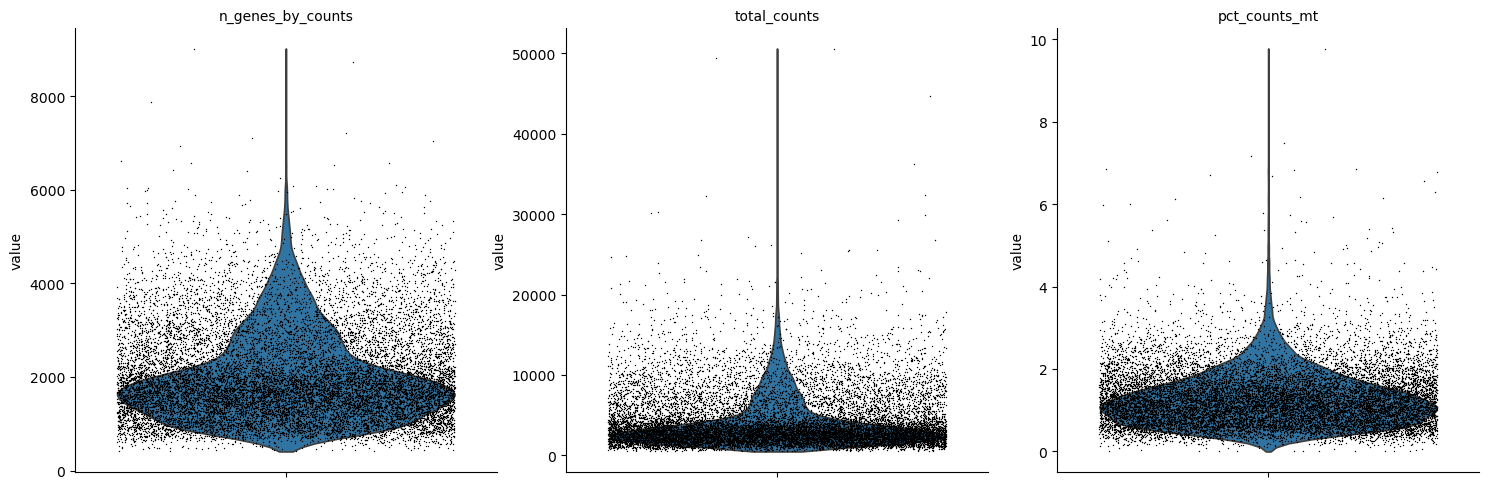

In [74]:
sc.pl.violin(
    adata1,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

(0.0, 30000.0)

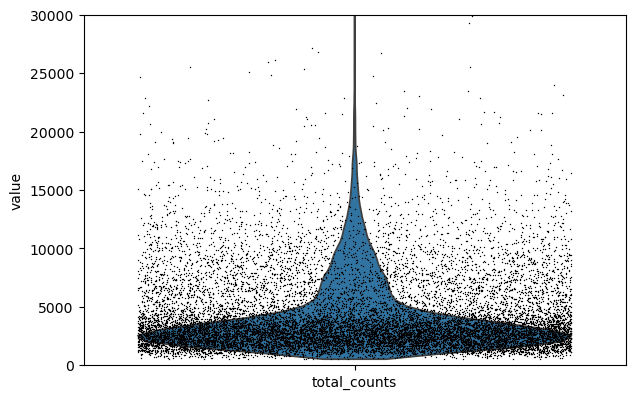

In [55]:
ax = sc.pl.violin(
    adata1,
    "total_counts",
    jitter=0.4,
    show=False
)

ax.set_ylim(0, 30000)

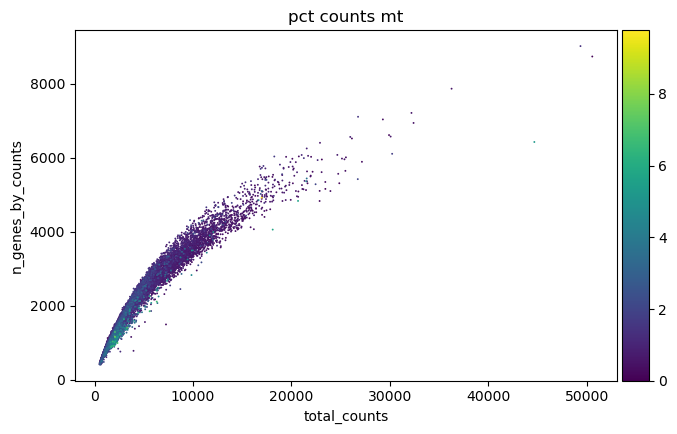

In [75]:
sc.pl.scatter(adata1, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [70]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata1.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [90]:
adata1.obs["outlier"] = (
    is_outlier(adata1, "log1p_total_counts", 5)
    | is_outlier(adata1, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata1, "pct_counts_in_top_20_genes", 5)
)
adata1.obs.outlier.value_counts()

outlier
False    16229
True       206
Name: count, dtype: int64

In [92]:
adata1.obs["mt_outlier"] = is_outlier(adata1, "pct_counts_mt", 3) | (
    adata1.obs["pct_counts_mt"] > 8
)
adata1.obs.mt_outlier.value_counts()

mt_outlier
False    15428
True      1007
Name: count, dtype: int64

In [99]:
print(f"Total number of cells: {adata1.n_obs}")
adata1filtered = adata1[(~adata1.obs.outlier) & (~adata1.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata1filtered.n_obs}")

Total number of cells: 16435
Number of cells after filtering of low quality cells: 15223


In [100]:
sc.pp.filter_genes(adata1filtered, min_cells=3)

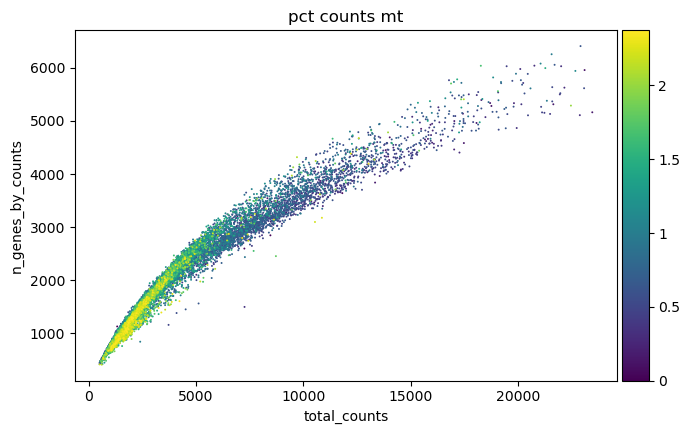

In [101]:
p1 = sc.pl.scatter(adata1filtered, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [86]:
adata1.obs[adata1.obs['n_genes_by_counts'] < 500]

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,pct_counts_in_top_20_genes,outlier
AAGCTTGTCAAGTCTG-1,431,6.068426,564.0,6.336826,26.595745,41.312057,59.042553,100.0,16.0,2.833213,2.836879,21.0,3.091043,3.723404,0.0,0.000000,0.000000,15.957447,False
ACAAGGCGTCCATCCT-1,456,6.124683,529.0,6.272877,23.251418,32.703214,51.606805,100.0,13.0,2.639057,2.457467,13.0,2.639057,2.457467,0.0,0.000000,0.000000,12.476371,False
ACACCCAGTTAGTGGA-1,474,6.163315,553.0,6.317165,23.327306,32.368897,50.452080,100.0,3.0,1.386294,0.542495,17.0,2.890372,3.074141,0.0,0.000000,0.000000,12.477396,False
ACACCCTCACTCAGGA-1,408,6.013715,611.0,6.416732,31.914894,48.281506,65.957447,100.0,13.0,2.639057,2.127660,22.0,3.135494,3.600655,0.0,0.000000,0.000000,19.476268,False
ACAGGATAGGCACGTT-1,488,6.192362,644.0,6.469250,26.242236,39.751553,55.279503,100.0,11.0,2.484907,1.708074,25.0,3.258096,3.881988,1.0,0.693147,0.155280,14.751553,False
ACCCAAATCATGGCCG-1,473,6.161207,623.0,6.436151,29.855538,40.128411,56.179775,100.0,11.0,2.484907,1.765650,16.0,2.833213,2.568218,1.0,0.693147,0.160514,20.224719,False
AGCGACAAGCCACATA-1,448,6.107023,511.0,6.238325,22.113503,31.898239,51.467710,100.0,3.0,1.386294,0.587084,21.0,3.091043,4.109589,0.0,0.000000,0.000000,13.307241,False
AGCTTATAGCTAGATT-1,491,6.198479,695.0,6.545350,26.906475,41.294964,58.129496,100.0,24.0,3.218876,3.453238,26.0,3.295837,3.741007,0.0,0.000000,0.000000,16.402878,False
ATAACGTTCCAATGCA-1,446,6.102559,735.0,6.601230,35.782313,49.387755,66.530612,100.0,10.0,2.397895,1.360544,22.0,3.135494,2.993197,0.0,0.000000,0.000000,23.265306,False
ATGGAGTAGGTGCGTT-1,485,6.186209,561.0,6.331502,22.459893,31.372549,49.197861,100.0,1.0,0.693147,0.178253,14.0,2.708050,2.495544,0.0,0.000000,0.000000,12.121212,False


In [87]:
adata1.var

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
Xkr4,ENSMUSG00000051951,Gene Expression,GRCm39,False,False,False,358,0.046486,0.045438,97.821722,764.0,6.639876
Gm1992,ENSMUSG00000089699,Gene Expression,GRCm39,False,False,False,12,0.000852,0.000851,99.926985,14.0,2.708050
Gm19938,ENSMUSG00000102331,Gene Expression,GRCm39,False,False,False,32,0.002434,0.002431,99.805294,40.0,3.713572
Gm37381,ENSMUSG00000102343,Gene Expression,GRCm39,False,False,False,7,0.000487,0.000487,99.957408,8.0,2.197225
Rp1,ENSMUSG00000025900,Gene Expression,GRCm39,False,False,False,157,0.019227,0.019045,99.044722,316.0,5.758902
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000


In [89]:
adata1.var[adata1.var['n_cells_by_counts'] < 3]

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
Gm37323,ENSMUSG00000104328,Gene Expression,GRCm39,False,False,False,1,0.000061,0.000061,99.993915,1.0,0.693147
Gm16041,ENSMUSG00000085623,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
Npbwr1,ENSMUSG00000033774,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
Gm30414,ENSMUSG00000103067,Gene Expression,GRCm39,False,False,False,2,0.000183,0.000183,99.987831,3.0,1.386294
Gm29520,ENSMUSG00000099827,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000095763,ENSMUSG00000095763,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000


# Ambient RNA check

In [105]:
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

rcb.logger.setLevel(logging.ERROR)


%load_ext rpy2.ipython

ModuleNotFoundError: No module named 'rpy2'